In [2]:
print("Growth Advisor AI is ready!")

Growth Advisor AI is ready!


In [3]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("marketing_campaign.csv", sep="\t")

# Display first rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
print("Rows, Columns:", df.shape)

Rows, Columns: (2240, 29)


In [5]:
# Check missing values

df.isnull().sum().sort_values(ascending=False)

Income                 24
ID                      0
NumDealsPurchases       0
Z_Revenue               0
Z_CostContact           0
Complain                0
AcceptedCmp2            0
AcceptedCmp1            0
AcceptedCmp5            0
AcceptedCmp4            0
AcceptedCmp3            0
NumWebVisitsMonth       0
NumStorePurchases       0
NumCatalogPurchases     0
NumWebPurchases         0
MntGoldProds            0
Year_Birth              0
MntSweetProducts        0
MntFishProducts         0
MntMeatProducts         0
MntFruits               0
MntWines                0
Recency                 0
Dt_Customer             0
Teenhome                0
Kidhome                 0
Marital_Status          0
Education               0
Response                0
dtype: int64

In [6]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [7]:
df["Income"].isnull().sum()

np.int64(24)

In [8]:
# Fill missing Income values with median

df["Income"] = df["Income"].fillna(df["Income"].median())

# Verify
print("Missing Income values:", df["Income"].isnull().sum())

Missing Income values: 0


In [9]:
# Create TotalSpend feature

df["TotalSpend"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

df["TotalSpend"].describe()

count    2240.000000
mean      605.798214
std       602.249288
min         5.000000
25%        68.750000
50%       396.000000
75%      1045.500000
max      2525.000000
Name: TotalSpend, dtype: float64

In [10]:
# Top spending customers

df[["Income", "TotalSpend"]].sort_values(
    by="TotalSpend",
    ascending=False
).head(10)

,Income,TotalSpend
1572,90638.0,2525
1179,90638.0,2525
1492,87679.0,2524
987,75759.0,2486
1052,69098.0,2440
1601,90226.0,2352
1458,93790.0,2349
1288,83151.0,2346
943,94384.0,2302
1301,94384.0,2302


In [11]:
# Top 10 spending customers

df[["ID", "Income", "TotalSpend"]].sort_values(
    by="TotalSpend",
    ascending=False
).head(10)

,ID,Income,TotalSpend
1572,5350,90638.0,2525
1179,5735,90638.0,2525
1492,1763,87679.0,2524
987,4580,75759.0,2486
1052,4475,69098.0,2440
1601,5453,90226.0,2352
1458,10133,93790.0,2349
1288,9010,83151.0,2346
943,5386,94384.0,2302
1301,6024,94384.0,2302


In [12]:
# Create High Value Customer flag

threshold = df["TotalSpend"].quantile(0.90)

df["HighValueCustomer"] = (
    df["TotalSpend"] >= threshold
).astype(int)

print("Threshold:", threshold)

df["HighValueCustomer"].value_counts()

Threshold: 1536.2000000000003


HighValueCustomer
0    2016
1     224
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


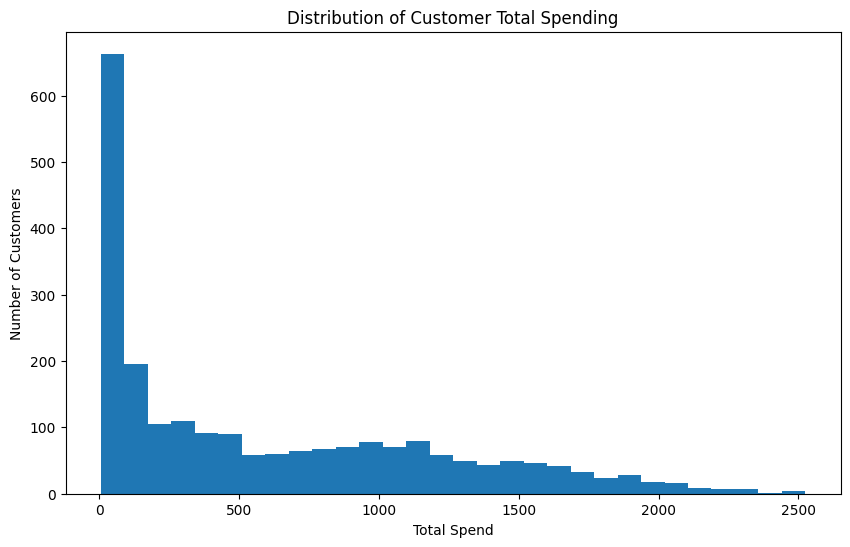

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df["TotalSpend"], bins=30)

plt.title("Distribution of Customer Total Spending")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")

plt.show()

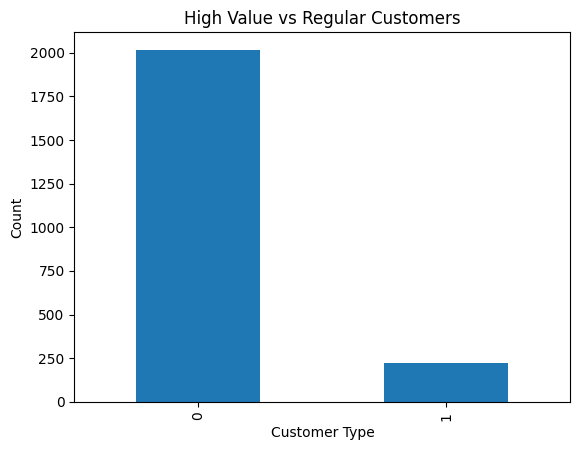

In [14]:
df["HighValueCustomer"].value_counts().plot(
    kind="bar"
)

plt.title("High Value vs Regular Customers")
plt.xlabel("Customer Type")
plt.ylabel("Count")

plt.show()

In [15]:
# Average income by customer segment

df.groupby("HighValueCustomer")["Income"].mean()

HighValueCustomer
0    49165.137153
1    79893.520089
Name: Income, dtype: float64

In [16]:
# Average spending by segment

df.groupby("HighValueCustomer")["TotalSpend"].mean()

HighValueCustomer
0     470.118552
1    1826.915179
Name: TotalSpend, dtype: float64

In [17]:
# Education distribution

pd.crosstab(
    df["Education"],
    df["HighValueCustomer"]
)

HighValueCustomer,0,1
Education,,
2n Cycle,193,10
Basic,54,0
Graduation,1014,113
Master,325,45
PhD,430,56


In [18]:
# Marital status distribution

pd.crosstab(
    df["Marital_Status"],
    df["HighValueCustomer"]
)

HighValueCustomer,0,1
Marital_Status,,
Absurd,2,0
Alone,3,0
Divorced,210,22
Married,787,77
Single,426,54
Together,518,62
Widow,68,9
YOLO,2,0


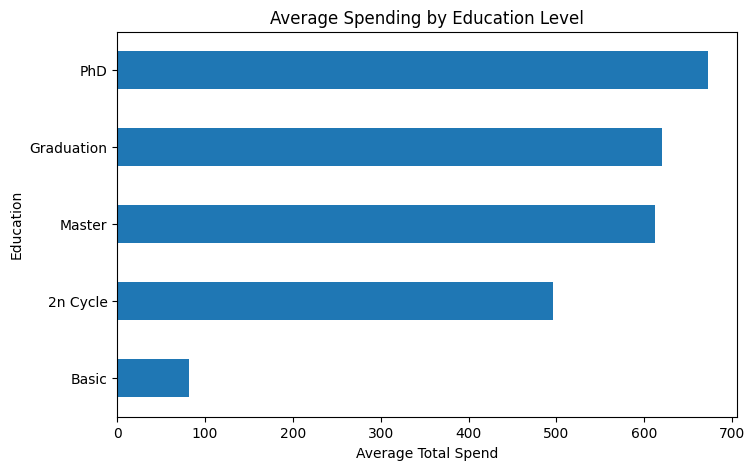

In [21]:
import matplotlib.pyplot as plt

df.groupby("Education")["TotalSpend"].mean().sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Average Spending by Education Level")
plt.xlabel("Average Total Spend")
plt.ylabel("Education")

plt.savefig(
    "education_spending_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
df.groupby("Marital_Status")["TotalSpend"].mean()

Marital_Status
Absurd      1192.500000
Alone        256.666667
Divorced     610.629310
Married      590.802083
Single       606.483333
Together     608.387931
Widow        738.818182
YOLO         424.000000
Name: TotalSpend, dtype: float64